# Titanic surviving prediction

I'm gonna use the dataset embedded in seaborn :)

## Load dataset and prepare the data
I'll remove embark_town, embarked from features cus I don't see any relation with the label

In [5]:
import seaborn as sns

data = sns.load_dataset('titanic')

data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [19]:
# Separate features and labels 
X = data.drop(['survived', 'embark_town', 'embarked', 'alive', 'who', 'deck'], axis=1)
X['age'] = X['age'].fillna(X['age'].mean())
X = X.fillna(0)
y = data['survived']

# Adjust bool to 0/1
X = X.replace({"True": 1, "False": 0, True: 1, False: 0})
y = y.replace({"yes": 1, "no": 0})

# Categorize X
cat_cols = ['pclass', 'sex', 'class', 'adult_male', 'alone']
num_cols = ['age', 'sibsp', 'parch']

In [20]:
# Normalize Data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_num = scaler.fit_transform(X[num_cols])

In [21]:
# One Hot Encode categorical features
from sklearn.preprocessing import OneHotEncoder
import numpy as np

enc = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)

X_cat = enc.fit_transform(X[cat_cols])
X_num = X[num_cols].to_numpy()

X_encoded = np.hstack([X_num, X_cat]).astype(np.float32)

In [22]:
# Split the data
from sklearn.model_selection import train_test_split

train_data, test_data, train_labels, test_labels = train_test_split(
    X_encoded, y, train_size=0.8
)

# Convert them into Pytorch Datasets
from torch.utils.data import DataLoader
import torch

train_data = torch.utils.data.TensorDataset(
    torch.tensor(train_data, dtype=torch.float32), 
    torch.tensor(train_labels.values, dtype=torch.float32).unsqueeze(1)
)

test_data = torch.utils.data.TensorDataset(
    torch.tensor(test_data, dtype=torch.float32), 
    torch.tensor(test_labels.values, dtype=torch.float32).unsqueeze(1)
)

# Translate into Dataloaders
train_loader = DataLoader(train_data, shuffle=True, batch_size=16)
test_loader = DataLoader(test_data, shuffle=True, batch_size=16)

## Deep Learning Job

In [23]:
import torch.nn as nn

# Creating my Neural Network
class SurvivorPredictorModel(nn.Module):

    # layers
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(10,32), # 10 inputs
            nn.ReLU(), # Logistic Regression

            nn.Linear(32, 16), # Combine patterns
            nn.ReLU(), # Logistic Regression

            nn.Linear(16,1) # Conclude One number
        )
        
        
    # forward propagation
    def forward(self, x):

        x = self.net(x)
        
        return x

In [24]:
# Declaring my Model
predictor = SurvivorPredictorModel()

# Tools
learningrate = 0.001

optimizer = torch.optim.Adam(predictor.parameters(), lr=learningrate)

'''
This loss function complete the probability calculation 
* Converts the logits to probability
'''
lossfun = nn.BCEWithLogitsLoss()

In [34]:
# Training my Model

num_epochs = 1000

trainAcc = []
testAcc = []
losses = []

# Iterate epochs
for epochi in range(num_epochs):

    '''
    Train
    '''
    predictor.train()
    batchAcc = []
    
    # Iterate loaders
    for X, y in train_loader:
        
        # forward
        yHat = predictor(X)
        loss = lossfun(yHat, y)
        losses.append(loss)
        
        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
        # Accuracy
        probs = torch.sigmoid(yHat)
        preds = (probs > 0.5).float()

        acc = 100*torch.mean((preds==y).float()).item()
        batchAcc.append(acc)

    trainAcc.append(np.mean(batchAcc))

    '''
    Test
    '''
    predictor.eval()
    with torch.no_grad():

        accs = []

        for X, y in test_loader:
            yHat = predictor(X)

            probs = torch.sigmoid(yHat)
            preds = (probs > 0.5).float()

            acc = 100*torch.mean((preds==y).float()).item()
            accs.append(acc)

            testAcc.append(np.mean(accs))

    print(f"Epoch {epochi}: Train {trainAcc[-1]:.2f} | Test {testAcc[-1]:.2f}")

Epoch 0: Train 85.28 | Test 78.99
Epoch 1: Train 85.28 | Test 79.51
Epoch 2: Train 85.56 | Test 76.74
Epoch 3: Train 85.69 | Test 76.91
Epoch 4: Train 85.69 | Test 79.69
Epoch 5: Train 85.56 | Test 81.77
Epoch 6: Train 85.42 | Test 80.73
Epoch 7: Train 83.61 | Test 78.65
Epoch 8: Train 85.28 | Test 73.61
Epoch 9: Train 85.83 | Test 76.22
Epoch 10: Train 84.72 | Test 78.12
Epoch 11: Train 85.56 | Test 79.69
Epoch 12: Train 84.58 | Test 81.25
Epoch 13: Train 85.28 | Test 76.91
Epoch 14: Train 85.00 | Test 77.95
Epoch 15: Train 84.44 | Test 76.91
Epoch 16: Train 85.14 | Test 75.17
Epoch 17: Train 85.42 | Test 80.21
Epoch 18: Train 84.44 | Test 76.91
Epoch 19: Train 84.58 | Test 76.39
Epoch 20: Train 85.28 | Test 81.25
Epoch 21: Train 84.86 | Test 77.43
Epoch 22: Train 85.69 | Test 77.95
Epoch 23: Train 85.42 | Test 78.65
Epoch 24: Train 85.56 | Test 81.77
Epoch 25: Train 85.56 | Test 76.39
Epoch 26: Train 85.00 | Test 78.47
Epoch 27: Train 85.42 | Test 81.25
Epoch 28: Train 85.14 | Test 7

In [35]:
print(f"Train accuracy:", np.array(trainAcc).mean())
print(f"Test accuracy:", np.array(testAcc).mean())

Train accuracy: 85.85444444444444
Test accuracy: 76.72272354020556


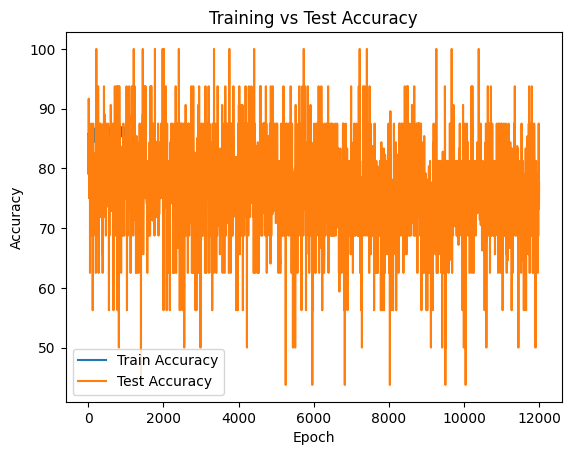

In [37]:
import matplotlib.pyplot as plt

plt.plot(trainAcc, label='Train Accuracy')
plt.plot(testAcc, label='Test Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Test Accuracy')

plt.legend()
plt.show()